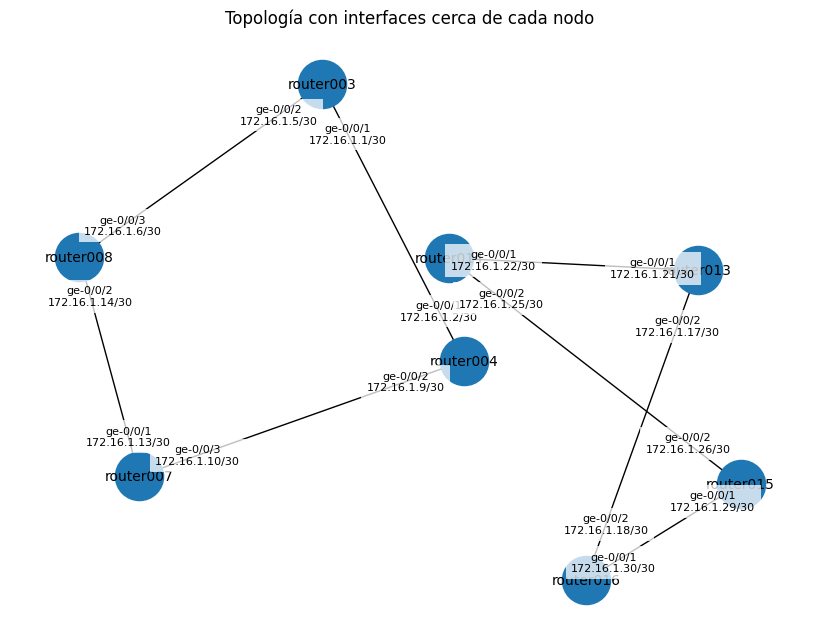

In [111]:
import networkx as nx
import matplotlib.pyplot as plt
import csv
import json
###
# Need to get data from routers
with open('vt1.txt', newline='') as f:
    reader = csv.reader(f)
    matriz = list(reader)

n = len(matriz)

for i in range(n):
    for j in range(n):
        matriz[i][j] = int(matriz[i][j])
        if matriz[i][j] == 0:
            matriz[i][j] = 64


with open('ddlist1.json', 'r') as file:
    ddlistp = json.load(file)
###

###
# So there is a problem with threading and the resulting data structure. It is the routers are disordered
# It is convenient to have ordered from smallest router to largest so we order here.
kl = [0 for _ in range(n)]
i = 0
for e in ddlistp:
    kl[i] = e
    i += 1

kl.sort()

ddlist = {}

for i in range(n):
    ddlist.update({kl[i]:ddlistp[kl[i]]})

###

###
# ind_t stores matrix names
ind_t = [0 for _ in range(n)]
i = 0
for e in ddlist:
    ind_t[i] = e
    ddlist[e].update({'num':i})
    i += 1
###

###
# preparing data structure for plotting
interfaces = {}
i = 0
for r in ddlist:
    for k,e in ddlist[r]['neighbors'].items():
        if ddlist[r]['num'] > ddlist[k]['num']:
            continue
        # r is local router
        # k is neighbor router
        # e is neighbor ip
        e += '/30'
        # le is local ip
        le = ddlist[k]['neighbors'][r] + '/30'
        # li is local if
        for k2,e2 in ddlist[r]['if_config'].items():
            if e2 == le:
                li = k2
                break
        # ei is external if
        for k2,e2 in ddlist[k]['if_config'].items():
            if e2 == e:
                ei = k2
                break

        interfaces.update({(ddlist[r]['num'],ddlist[k]['num']):((li,le),(ei,e))})
###

NO_CONEXION = 64
G = nx.Graph()

# Crear nodos
for i in range(n):
    G.add_node(f"{ind_t[i]}")

for i in range(n):
    for j in range(i + 1, n):
        if matriz[i][j] != NO_CONEXION:
            if1, if2 = interfaces.get((i, j), (("?","?"), ("?","?")))

            G.add_edge(
                f"{ind_t[i]}",
                f"{ind_t[j]}",
                weight=matriz[i][j],
                interface_i= if1[0] + '\n' + if1[1],
                interface_j= if2[0] + '\n' + if2[1],
            )

pos = nx.spring_layout(G, seed=42, k=1.5)

# Dibujar nodos y enlaces
plt.figure(figsize=(8, 6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1200,
    font_size=10
)

def poner_etiqueta_cerca_de_nodo(pos_u, pos_v, texto, t=0.18):
    """
    t controla qué tan cerca queda la etiqueta del nodo u.
    t = 0.0 está encima de u
    t = 0.5 está en medio del enlace
    t = 1.0 está encima de v
    """
    x = pos_u[0] * (1 - t) + pos_v[0] * t
    y = pos_u[1] * (1 - t) + pos_v[1] * t

    plt.text(
        x,
        y,
        texto,
        fontsize=8,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75),
        horizontalalignment="center",
        verticalalignment="center"
    )

for u, v, data in G.edges(data=True):
    # Etiqueta cerca del nodo u
    poner_etiqueta_cerca_de_nodo(
        pos[u],
        pos[v],
        data["interface_i"],
        t=0.18
    )

    # Etiqueta cerca del nodo v
    poner_etiqueta_cerca_de_nodo(
        pos[v],
        pos[u],
        data["interface_j"],
        t=0.18
    )

plt.title("Topología con interfaces cerca de cada nodo")
plt.axis("off")
plt.show()

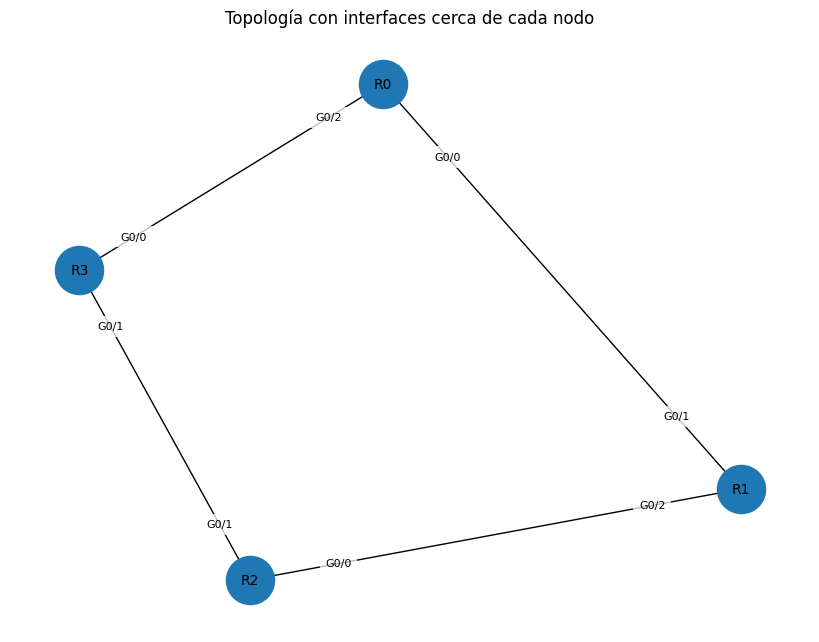

In [112]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

matriz = np.array([
    [64,  1, 64,  4],
    [ 1, 64,  2, 64],
    [64,  2, 64,  3],
    [ 4, 64,  3, 64]
])

interfaces = {
    (0, 1): ("G0/0", "G0/1"),
    (0, 3): ("G0/2", "G0/0"),
    (1, 2): ("G0/2", "G0/0"),
    (2, 3): ("G0/1", "G0/1")
}

NO_CONEXION = 64
G = nx.Graph()

n = len(matriz)

for i in range(n):
    G.add_node(f"R{i}")

for i in range(n):
    for j in range(i + 1, n):
        if matriz[i][j] != NO_CONEXION:
            int_i, int_j = interfaces.get((i, j), ("?", "?"))

            G.add_edge(
                f"R{i}",
                f"R{j}",
                weight=matriz[i][j],
                interface_i=int_i,
                interface_j=int_j
            )

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(8, 6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1200,
    font_size=10
)

def poner_etiqueta_cerca_de_nodo(pos_u, pos_v, texto, t=0.18):
    """
    t controla qué tan cerca queda la etiqueta del nodo u.
    t = 0.0 está encima de u
    t = 0.5 está en medio del enlace
    t = 1.0 está encima de v
    """
    x = pos_u[0] * (1 - t) + pos_v[0] * t
    y = pos_u[1] * (1 - t) + pos_v[1] * t

    plt.text(
        x,
        y,
        texto,
        fontsize=8,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75),
        horizontalalignment="center",
        verticalalignment="center"
    )

for u, v, data in G.edges(data=True):
    # Etiqueta cerca del nodo u
    poner_etiqueta_cerca_de_nodo(
        pos[u],
        pos[v],
        data["interface_i"],
        t=0.18
    )

    # Etiqueta cerca del nodo v
    poner_etiqueta_cerca_de_nodo(
        pos[v],
        pos[u],
        data["interface_j"],
        t=0.18
    )

plt.title("Topología con interfaces cerca de cada nodo")
plt.axis("off")
plt.show()